# 🧠 Notebook 5: Self-Attention Mechanism

**The Core Innovation of Transformers**

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. Understand **why attention is needed**
2. Implement **Query, Key, Value** matrices
3. Calculate **attention scores** (dot product)
4. Apply **softmax** for attention weights
5. Implement **causal masking** for autoregressive generation
6. Visualize **attention patterns**
7. Build a complete **Self-Attention layer**

---

## 📚 Table of Contents

1. [The Communication Problem](#1-the-communication-problem)
2. [Intuition: Attention as Information Retrieval](#2-intuition-attention-as-information-retrieval)
3. [Query, Key, Value (QKV)](#3-query-key-value-qkv)
4. [Attention Scores](#4-attention-scores)
5. [Scaled Dot-Product Attention](#5-scaled-dot-product-attention)
6. [Causal Masking](#6-causal-masking)
7. [Complete Self-Attention Implementation](#7-complete-self-attention-implementation)
8. [Attention Visualization](#8-attention-visualization)
9. [Key Takeaways](#9-key-takeaways)

In [5]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle
import os

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

print("✅ Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ Libraries imported successfully!
PyTorch version: 2.10.0+cpu


### Environment Setup (Colab/Local)

This cell detects whether you're running in Google Colab or locally and sets up the environment accordingly.

In [6]:
# ========================================
# ENVIRONMENT DETECTION & SETUP
# ========================================

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except:
    IN_COLAB = False
    print("Running locally")

# Setup directories
if IN_COLAB:
    # Create necessary directories for Colab
    os.makedirs('data', exist_ok=True)
    os.makedirs('visualizations/tokenization', exist_ok=True)
    os.makedirs('visualizations/embeddings', exist_ok=True)
    os.makedirs('visualizations/data_pipeline', exist_ok=True)
    print("Created directories")
    
    # Set paths for Colab
    DATA_DIR = 'data'
    VIZ_DIR = 'visualizations'
else:
    # Use relative paths for local execution
    DATA_DIR = '../data'
    VIZ_DIR = '../visualizations'
    
    # Create directories if they don't exist (LOCAL FIX)
    os.makedirs(DATA_DIR, exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/tokenization', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/embeddings', exist_ok=True)
    os.makedirs(f'{VIZ_DIR}/data_pipeline', exist_ok=True)
    print(f"Created directories: {DATA_DIR}, {VIZ_DIR}")

print(f"\nData directory: {DATA_DIR}")
print(f"Visualization directory: {VIZ_DIR}")

Running in Google Colab
Created directories

Data directory: data
Visualization directory: visualizations


In [7]:
# ========================================
# LOAD OR GENERATE CONFIGURATION
# ========================================
# This cell loads config from previous notebooks if available,
# or generates it from scratch so notebook 05 works standalone on Colab.

import urllib.request

config_path    = f'{DATA_DIR}/data_config.pkl'
embedding_path = f'{DATA_DIR}/embedding_layer.pth'

if os.path.exists(config_path) and os.path.exists(embedding_path):
    # ── Files exist: load from previous notebooks ──────────────────
    with open(config_path, 'rb') as f:
        config = pickle.load(f)
    vocab_size = config['vocab_size']
    block_size = config['block_size']
    batch_size = config['batch_size']

    checkpoint = torch.load(embedding_path, map_location='cpu')
    n_embd = checkpoint['n_embd']
    print('✅ Loaded configuration from previous notebooks')

else:
    # ── Files missing: generate from scratch ───────────────────────
    print('⚠️  Previous notebook files not found — generating from scratch...')

    # Default hyperparameters (same as notebook 04)
    block_size = 8
    batch_size = 4
    n_embd     = 32

    # Download Shakespeare text to build vocabulary
    sample_path = f'{DATA_DIR}/sample.txt'
    if not os.path.exists(sample_path):
        url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
        print('📥 Downloading Shakespeare text...')
        try:
            urllib.request.urlretrieve(url, sample_path)
            print('✅ Downloaded successfully')
        except Exception as e:
            print(f'⚠️  Download failed ({e}), using default vocab_size=65')

    if os.path.exists(sample_path):
        with open(sample_path, 'r', encoding='utf-8') as f:
            text = f.read()
        chars      = sorted(list(set(text)))
        vocab_size = len(chars)
        stoi       = {ch: i for i, ch in enumerate(chars)}
        itos       = {i: ch for i, ch in enumerate(chars)}
        print(f'✅ Built vocabulary: {vocab_size} unique characters')
    else:
        vocab_size = 65          # standard Shakespeare char-level vocab
        stoi, itos = {}, {}
        print(f'✅ Using default vocab_size={vocab_size}')

    # Save data_config.pkl
    config = {
        'vocab_size': vocab_size,
        'block_size': block_size,
        'batch_size': batch_size,
        'stoi': stoi,
        'itos': itos
    }
    with open(config_path, 'wb') as f:
        pickle.dump(config, f)
    print('✅ Saved data_config.pkl')

    # Create and save embedding layer
    class EmbeddingLayer(nn.Module):
        def __init__(self, vocab_size, block_size, n_embd):
            super().__init__()
            self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
            self.position_embedding_table = nn.Embedding(block_size, n_embd)
            self.block_size = block_size
        def forward(self, idx):
            B, T = idx.shape
            tok_emb = self.token_embedding_table(idx)
            pos_emb = self.position_embedding_table(
                torch.arange(T, device=idx.device)
            )
            return tok_emb + pos_emb

    embedding_layer = EmbeddingLayer(vocab_size, block_size, n_embd)
    torch.save(
        {
            'embedding_layer': embedding_layer.state_dict(),
            'vocab_size': vocab_size,
            'block_size': block_size,
            'n_embd': n_embd
        },
        embedding_path
    )
    print('✅ Saved embedding_layer.pth')

print(f'\n📊 Configuration:')
print(f'   Vocabulary size : {vocab_size}')
print(f'   Block size      : {block_size}')
print(f'   Batch size      : {batch_size}')
print(f'   Embedding dim   : {n_embd}')


⚠️  Previous notebook files not found — generating from scratch...
✅ Built vocabulary: 65 unique characters
✅ Saved data_config.pkl
✅ Saved embedding_layer.pth

📊 Configuration:
   Vocabulary size : 65
   Block size      : 8
   Batch size      : 4
   Embedding dim   : 32


---

## 1. The Communication Problem

### 🚨 The Issue

After embeddings, each token has a vector representation:

```
Sentence: "The cat sat on the mat"
Embeddings: [v_the, v_cat, v_sat, v_on, v_the, v_mat]
```

**Problem:** Each token's embedding is **independent**!

- "cat" doesn't know it's the subject of "sat"
- "sat" doesn't know what's sitting
- "mat" doesn't know what's on it

### 💡 The Solution: Self-Attention

**Self-Attention** allows tokens to "look at" and "gather information from" other tokens in the sequence.

**Key Idea:** Each token asks:
- "Which other tokens are relevant to me?"
- "How much should I pay attention to each one?"
- "What information should I gather from them?"

---

## 2. Intuition: Attention as Information Retrieval

### 🔍 Library Analogy

Imagine you're in a library looking for information:

1. **Query (Q)**: Your question - "What are you looking for?"
   - Example: "Books about machine learning"

2. **Key (K)**: Book titles/descriptions - "What does each book offer?"
   - Example: "Deep Learning", "Python Basics", "ML Algorithms"

3. **Value (V)**: Book contents - "What information does each book contain?"
   - Example: Actual content of each book

**Process:**
1. Compare your Query with each Key (similarity)
2. Books with matching Keys get higher attention scores
3. Retrieve and combine Values based on attention scores

### 🧠 In Transformers

Each token:
- Creates a **Query**: "What am I looking for?"
- Creates a **Key**: "What do I offer?"
- Creates a **Value**: "What information do I contain?"

Then:
- Compare each Query with all Keys
- Calculate attention weights (how relevant each token is)
- Aggregate Values based on these weights

---

## 3. Query, Key, Value (QKV)

### 📐 Mathematical Definition

Given input embeddings **X** of shape (B, T, C):

```
Q = X @ W_q    (Query matrix)
K = X @ W_k    (Key matrix)
V = X @ W_v    (Value matrix)
```

Where:
- W_q, W_k, W_v are learnable weight matrices
- Shape: (C, head_size) where head_size is typically C // num_heads

### 💻 Implementation

# Self-Attention: W_q, W_k, W_v Explained

---

## Q1: What are W_q, W_k, W_v?

These are **learned weight matrices** trained through backpropagation,
just like any other neural network weights.

```python
W_q = nn.Linear(d_model, d_k)  # Query  - "What am I looking for?"
W_k = nn.Linear(d_model, d_k)  # Key    - "What do I contain?"
W_v = nn.Linear(d_model, d_k)  # Value  - "What do I actually give out?"
```

When you pass an input `x`:

```
Q = x @ W_q
K = x @ W_k
V = x @ W_v
```

| Matrix | Learns to... |
|--------|--------------|
| `W_q`  | Ask the **right questions** |
| `W_k`  | **Advertise** its content |
| `W_v`  | **Extract** useful information |

> They start as **random values** and gradually learn through training.
> You never manually define them — the model figures it out.

---

## Q2: How do gradients flow through attention?

### Flow Diagram

```
x (input tokens)
│
├──→ x @ W_q = Q ──┐
├──→ x @ W_k = K ──┼──→ scores = Q @ Kᵀ / √d_k
└──→ x @ W_v = V   │         │
                   │    softmax(scores) = attn_weights
                   │         │
                   └─────────┼──→ attn_weights @ V = output
                             │
                           loss = f(output, target)
                             │
                    ←────────┘  loss.backward()
                    │
              gradients flow back through V, Q, K
                    │
              W_q.grad, W_k.grad, W_v.grad computed
                    │
              optimizer.step() updates the weights
```

### Simple Worked Example

```python
import torch, math
import torch.nn.functional as F

d_model, d_k = 4, 3
W_q = torch.randn(d_model, d_k, requires_grad=True)
W_k = torch.randn(d_model, d_k, requires_grad=True)
W_v = torch.randn(d_model, d_k, requires_grad=True)

x = torch.randn(2, d_model)   # 2 tokens

# Forward
Q      = x @ W_q
K      = x @ W_k
V      = x @ W_v
scores = Q @ K.T / math.sqrt(d_k)
attn   = F.softmax(scores, dim=-1)
output = attn @ V

# Backward
loss = ((output - torch.zeros_like(output)) ** 2).mean()
loss.backward()

# Gradients now available
print(W_q.grad)   # how to update W_q
print(W_k.grad)   # how to update W_k
print(W_v.grad)   # how to update W_v

# Update weights
with torch.no_grad():
    W_q -= 0.01 * W_q.grad
    W_k -= 0.01 * W_k.grad
    W_v -= 0.01 * W_v.grad
```

| Gradient   | Tells the model...                              |
|------------|-------------------------------------------------|
| `W_q.grad` | How to change **what you look for**             |
| `W_k.grad` | How to change **what you advertise**            |
| `W_v.grad` | How to change **what you output**               |

---

## Q3: Full Training Loop with Real Sentences

**Goal:** Train a model to predict the next word.

```python
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ── Vocabulary ──────────────────────────────────────────────────
vocab = {
    "<pad>": 0, "the": 1, "cat": 2, "sat": 3,
    "on":    4, "mat": 5, "dog": 6, "ran": 7
}
idx_to_word = {v: k for k, v in vocab.items()}
vocab_size   = len(vocab)

# Input  → ["the", "cat", "sat", "on",  "the"]
# Target → ["cat", "sat", "on",  "mat", "mat"]
inputs  = torch.tensor([[1, 2, 3, 4, 1]])
targets = torch.tensor([[2, 3, 4, 5, 5]])


# ── Model ───────────────────────────────────────────────────────
class SelfAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.W_q   = nn.Linear(d_model, d_k, bias=False)
        self.W_k   = nn.Linear(d_model, d_k, bias=False)
        self.W_v   = nn.Linear(d_model, d_k, bias=False)
        self.scale = math.sqrt(d_k)

    def forward(self, x):
        Q            = self.W_q(x)
        K            = self.W_k(x)
        V            = self.W_v(x)
        scores       = Q @ K.transpose(-2, -1) / self.scale
        attn_weights = F.softmax(scores, dim=-1)
        return attn_weights @ V, attn_weights


class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=16, d_k=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.attention = SelfAttention(d_model, d_k)
        self.fc_out    = nn.Linear(d_k, vocab_size)

    def forward(self, x):
        x, attn = self.attention(self.embedding(x))
        return self.fc_out(x), attn


# ── Training Loop ───────────────────────────────────────────────
model     = MiniTransformer(vocab_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    logits, attn_weights = model(inputs)

    loss = F.cross_entropy(
        logits.view(-1, vocab_size),
        targets.view(-1)
    )

    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute gradients → W_q, W_k, W_v
    optimizer.step()        # 3. update all weights

    if epoch % 40 == 0:
        preds = [idx_to_word[i.item()] for i in logits.argmax(-1)[0]]
        print(f"Epoch {epoch:>3}  Loss: {loss.item():.4f}  Preds: {preds}")
```

### What Happens Each Epoch

```
Epoch 0:   random weights → loss high (~2.1) → predictions garbage
Epoch 40:  weights improving → loss drops (~1.2)
Epoch 100: weights much better → loss low (~0.3)
Epoch 200: W_q, W_k, W_v fully learned → correct predictions ✅
```

### Key Takeaway

> You **never manually set** W_q, W_k, W_v.
> The training loop discovers the best values automatically
> by minimizing the loss over many examples.

In [8]:
# Hyperparameters
head_size = 16  # Dimension of Q, K, V

# Create sample embeddings
B, T, C = 4, 8, n_embd  # Batch=4, Sequence=8, Channels=32
x = torch.randn(B, T, C)

print(f"📊 Input shape: {x.shape}")
print(f"   Batch size (B):     {B}")
print(f"   Sequence length (T): {T}")
print(f"   Embedding dim (C):   {C}")

📊 Input shape: torch.Size([4, 8, 32])
   Batch size (B):     4
   Sequence length (T): 8
   Embedding dim (C):   32


In [9]:
# Create QKV projection layers
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

# Project to Q, K, V
k = key(x)    # (B, T, head_size)
q = query(x)  # (B, T, head_size)
v = value(x)  # (B, T, head_size)

print(f"\n🔑 Key shape:   {k.shape}")
print(f"❓ Query shape: {q.shape}")
print(f"💎 Value shape: {v.shape}")

print(f"\n💡 Each token now has:")
print(f"   - A Query vector (what it's looking for)")
print(f"   - A Key vector (what it offers)")
print(f"   - A Value vector (information it contains)")


🔑 Key shape:   torch.Size([4, 8, 16])
❓ Query shape: torch.Size([4, 8, 16])
💎 Value shape: torch.Size([4, 8, 16])

💡 Each token now has:
   - A Query vector (what it's looking for)
   - A Key vector (what it offers)
   - A Value vector (information it contains)


### 📊 Visualize QKV

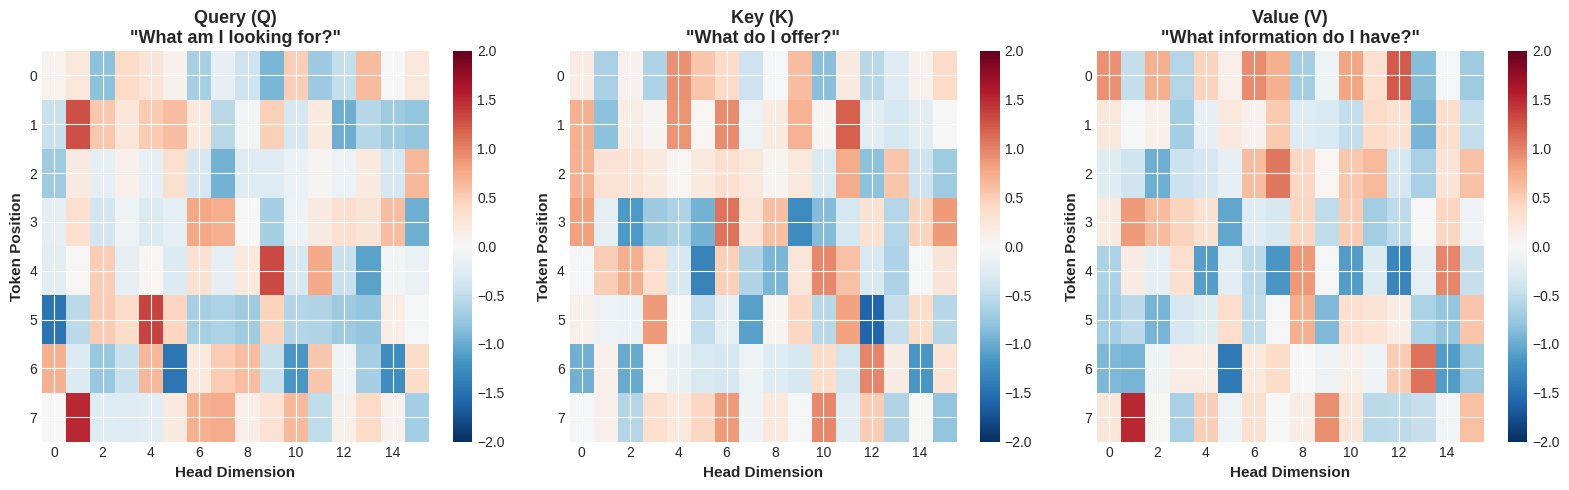


💡 Each row represents one token's Q/K/V vector


In [10]:
# Visualize Q, K, V for first sequence
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Query
im1 = axes[0].imshow(q[0].detach().numpy(), cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
axes[0].set_xlabel('Head Dimension', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Token Position', fontsize=11, fontweight='bold')
axes[0].set_title('Query (Q)\n"What am I looking for?"', fontsize=13, fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# Key
im2 = axes[1].imshow(k[0].detach().numpy(), cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
axes[1].set_xlabel('Head Dimension', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Token Position', fontsize=11, fontweight='bold')
axes[1].set_title('Key (K)\n"What do I offer?"', fontsize=13, fontweight='bold')
plt.colorbar(im2, ax=axes[1])

# Value
im3 = axes[2].imshow(v[0].detach().numpy(), cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
axes[2].set_xlabel('Head Dimension', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Token Position', fontsize=11, fontweight='bold')
axes[2].set_title('Value (V)\n"What information do I have?"', fontsize=13, fontweight='bold')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/qkv_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Each row represents one token's Q/K/V vector")

---

## 4. Attention Scores

### 🎯 Computing Similarity

**Goal:** For each token, determine how much attention to pay to every other token.

**Method:** Dot product between Query and Key

```
Attention Scores = Q @ K^T
```

**Shape:**
- Q: (B, T, head_size)
- K^T: (B, head_size, T)
- Result: (B, T, T) - Each token attends to every token

### 💻 Implementation

In [11]:
# Compute attention scores (affinities)
# q @ k.transpose(-2, -1) means: for each query, dot product with all keys
wei = q @ k.transpose(-2, -1)  # (B, T, T)

print(f"📊 Attention scores shape: {wei.shape}")
print(f"   (Batch, Query_Tokens, Key_Tokens)")
print(f"\n🔍 First sequence attention scores:")
print(wei[0])
print(f"\n💡 wei[i, j] = how much token i attends to token j")

📊 Attention scores shape: torch.Size([4, 8, 8])
   (Batch, Query_Tokens, Key_Tokens)

🔍 First sequence attention scores:
tensor([[-1.2406, -2.2763, -0.5922,  0.0845, -0.7616, -0.2190,  1.5061, -0.0566],
        [ 1.0408,  0.5493,  2.0482, -3.6013,  0.9852,  2.7452, -1.0356,  0.5426],
        [ 0.1744, -1.1522, -0.8530, -0.8179,  0.2436,  0.5445,  1.6003, -0.8507],
        [-1.4276, -0.6412,  0.5336,  1.9831, -0.5529, -0.8732, -0.1925,  1.3468],
        [ 1.8492,  2.5459,  0.7907, -1.2669,  1.9497,  2.6025, -1.7415, -0.1127],
        [ 2.6747, -0.0138, -1.2764, -4.0871, -0.1163,  2.2977, -0.1412, -0.7361],
        [ 1.1826,  2.1935,  0.6451,  5.0398, -0.2729,  0.5885,  1.0114, -1.1239],
        [-1.8484, -1.4337,  0.8136, -0.2959,  0.0116, -1.9773,  0.2444,  1.9289]],
       grad_fn=<SelectBackward0>)

💡 wei[i, j] = how much token i attends to token j


### 📊 Visualize Raw Attention Scores

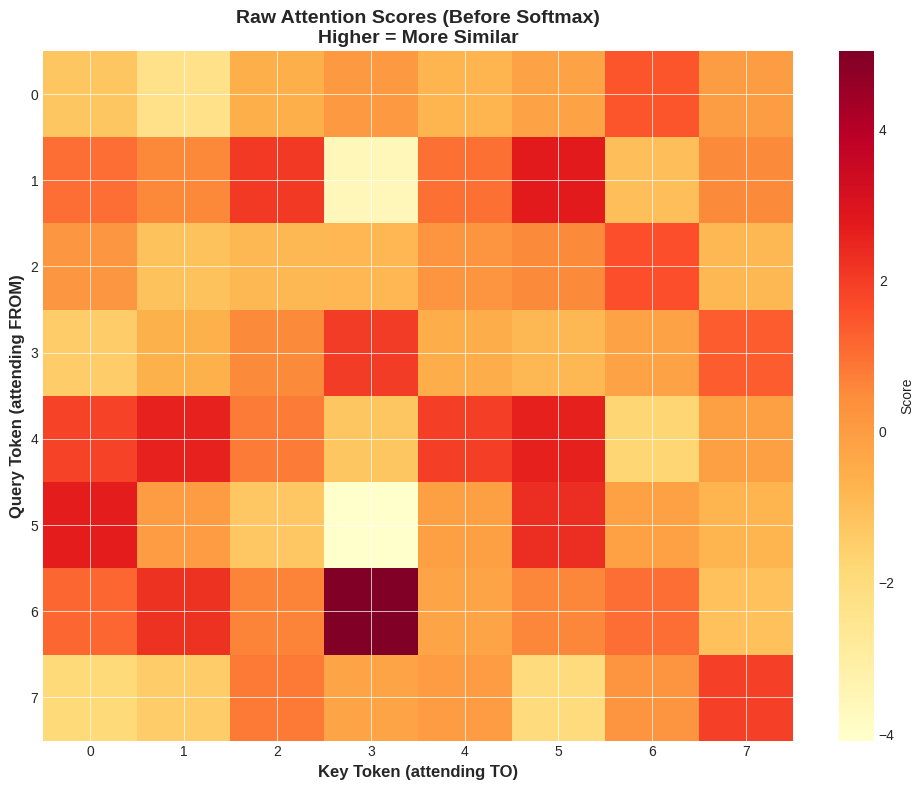


💡 Brighter = Higher attention (more similar Q and K)


In [12]:
# Visualize attention scores
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(wei[0].detach().numpy(), cmap='YlOrRd', aspect='auto')
ax.set_xlabel('Key Token (attending TO)', fontsize=12, fontweight='bold')
ax.set_ylabel('Query Token (attending FROM)', fontsize=12, fontweight='bold')
ax.set_title('Raw Attention Scores (Before Softmax)\nHigher = More Similar', 
             fontsize=14, fontweight='bold')

# Add grid
ax.set_xticks(range(T))
ax.set_yticks(range(T))
ax.grid(which='both', color='white', linewidth=0.5)

plt.colorbar(im, ax=ax, label='Score')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/raw_attention_scores.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Brighter = Higher attention (more similar Q and K)")

---

## 5. Scaled Dot-Product Attention

### ⚠️ The Scaling Problem

**Issue:** As head_size increases, dot products grow large in magnitude.

**Why it matters:** Large values → softmax saturates → gradients vanish

**Solution:** Scale by √(head_size)

```
Attention Scores = (Q @ K^T) / √(head_size)
```

### 💻 Implementation

In [13]:
# Scale attention scores
wei_scaled = wei / (head_size ** 0.5)

print(f"📊 Before scaling:")
print(f"   Mean: {wei[0].mean():.4f}")
print(f"   Std:  {wei[0].std():.4f}")
print(f"   Max:  {wei[0].max():.4f}")

print(f"\n📊 After scaling by √{head_size} = {head_size**0.5:.2f}:")
print(f"   Mean: {wei_scaled[0].mean():.4f}")
print(f"   Std:  {wei_scaled[0].std():.4f}")
print(f"   Max:  {wei_scaled[0].max():.4f}")

print(f"\n💡 Scaling prevents softmax saturation and gradient issues")

📊 Before scaling:
   Mean: 0.1673
   Std:  1.5853
   Max:  5.0398

📊 After scaling by √16 = 4.00:
   Mean: 0.0418
   Std:  0.3963
   Max:  1.2599

💡 Scaling prevents softmax saturation and gradient issues


### 🎯 Apply Softmax

Convert scores to probabilities (attention weights):

```
Attention Weights = softmax(Scaled Scores)
```

**Properties:**
- All weights are positive
- Weights sum to 1 for each query token
- Interpretable as "how much to attend"

In [14]:
# Apply softmax to get attention weights
wei_softmax = F.softmax(wei_scaled, dim=-1)  # Softmax over keys (last dimension)

print(f"📊 Attention weights shape: {wei_softmax.shape}")
print(f"\n🔍 First token's attention weights:")
print(wei_softmax[0, 0])  # How much token 0 attends to all tokens
print(f"\nSum: {wei_softmax[0, 0].sum():.4f} (should be 1.0)")

print(f"\n💡 These are probabilities - they sum to 1!")

📊 Attention weights shape: torch.Size([4, 8, 8])

🔍 First token's attention weights:
tensor([0.0991, 0.0765, 0.1165, 0.1380, 0.1117, 0.1279, 0.1969, 0.1332],
       grad_fn=<SelectBackward0>)

Sum: 1.0000 (should be 1.0)

💡 These are probabilities - they sum to 1!


### 📊 Visualize Attention Weights

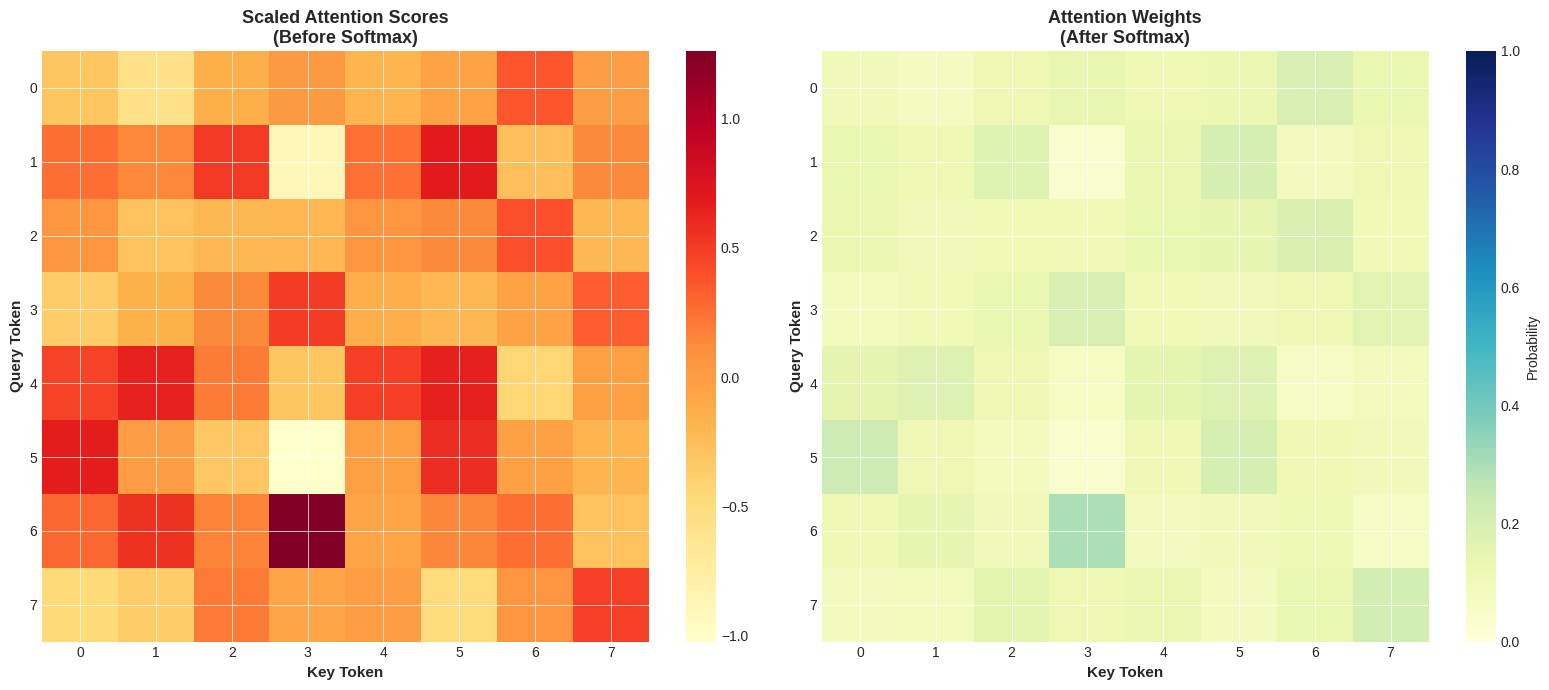


💡 After softmax, each row sums to 1 (probability distribution)


In [15]:
# Visualize attention weights
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Before softmax
im1 = axes[0].imshow(wei_scaled[0].detach().numpy(), cmap='YlOrRd', aspect='auto')
axes[0].set_xlabel('Key Token', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Query Token', fontsize=11, fontweight='bold')
axes[0].set_title('Scaled Attention Scores\n(Before Softmax)', fontsize=13, fontweight='bold')
axes[0].grid(which='both', color='white', linewidth=0.5)
plt.colorbar(im1, ax=axes[0])

# After softmax
im2 = axes[1].imshow(wei_softmax[0].detach().numpy(), cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
axes[1].set_xlabel('Key Token', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Query Token', fontsize=11, fontweight='bold')
axes[1].set_title('Attention Weights\n(After Softmax)', fontsize=13, fontweight='bold')
axes[1].grid(which='both', color='white', linewidth=0.5)
plt.colorbar(im2, ax=axes[1], label='Probability')

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/attention_weights.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 After softmax, each row sums to 1 (probability distribution)")

---

## 6. Causal Masking

### 🚨 The Future Information Problem

**Issue:** In autoregressive generation, tokens shouldn't see future tokens!

```
Predicting: "The cat sat on the ___"
           
Token "cat" should NOT see "sat", "on", "the" (they come after!)
```

**Solution:** **Causal Masking** - Set future attention scores to -∞

### 💻 Implementation

In [16]:
# Create causal mask (lower triangular matrix)
tril = torch.tril(torch.ones(T, T))

print(f"🎭 Causal Mask (Lower Triangular):")
print(tril)
print(f"\n💡 1 = can attend, 0 = cannot attend (future)")

🎭 Causal Mask (Lower Triangular):
tensor([[1., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])

💡 1 = can attend, 0 = cannot attend (future)


In [17]:
# Apply mask: set future positions to -inf
wei_masked = wei_scaled.masked_fill(tril == 0, float('-inf'))

print(f"📊 Masked attention scores (first sequence):")
print(wei_masked[0])
print(f"\n💡 -inf values will become 0 after softmax")

📊 Masked attention scores (first sequence):
tensor([[-0.3102,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.2602,  0.1373,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf],
        [ 0.0436, -0.2880, -0.2132,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.3569, -0.1603,  0.1334,  0.4958,    -inf,    -inf,    -inf,    -inf],
        [ 0.4623,  0.6365,  0.1977, -0.3167,  0.4874,    -inf,    -inf,    -inf],
        [ 0.6687, -0.0035, -0.3191, -1.0218, -0.0291,  0.5744,    -inf,    -inf],
        [ 0.2957,  0.5484,  0.1613,  1.2599, -0.0682,  0.1471,  0.2529,    -inf],
        [-0.4621, -0.3584,  0.2034, -0.0740,  0.0029, -0.4943,  0.0611,  0.4822]],
       grad_fn=<SelectBackward0>)

💡 -inf values will become 0 after softmax


In [18]:
# Apply softmax after masking
wei_masked_softmax = F.softmax(wei_masked, dim=-1)

print(f"📊 Attention weights after masking:")
print(wei_masked_softmax[0])
print(f"\n💡 Upper triangle is now all zeros (no future information!)")
print(f"\n🔍 Token 0 attends only to itself: {wei_masked_softmax[0, 0]}")
print(f"🔍 Token 3 attends to tokens 0-3: {wei_masked_softmax[0, 3]}")

📊 Attention weights after masking:
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5307, 0.4693, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4014, 0.2881, 0.3105, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1614, 0.1965, 0.2635, 0.3786, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2251, 0.2680, 0.1728, 0.1033, 0.2308, 0.0000, 0.0000, 0.0000],
        [0.2878, 0.1469, 0.1072, 0.0531, 0.1432, 0.2619, 0.0000, 0.0000],
        [0.1205, 0.1551, 0.1053, 0.3160, 0.0837, 0.1039, 0.1154, 0.0000],
        [0.0810, 0.0898, 0.1576, 0.1194, 0.1289, 0.0784, 0.1367, 0.2082]],
       grad_fn=<SelectBackward0>)

💡 Upper triangle is now all zeros (no future information!)

🔍 Token 0 attends only to itself: tensor([1., 0., 0., 0., 0., 0., 0., 0.], grad_fn=<SelectBackward0>)
🔍 Token 3 attends to tokens 0-3: tensor([0.1614, 0.1965, 0.2635, 0.3786, 0.0000, 0.0000, 0.0000, 0.0000],
       grad_fn=<SelectBackward0>)


### 📊 Visualize Causal Masking

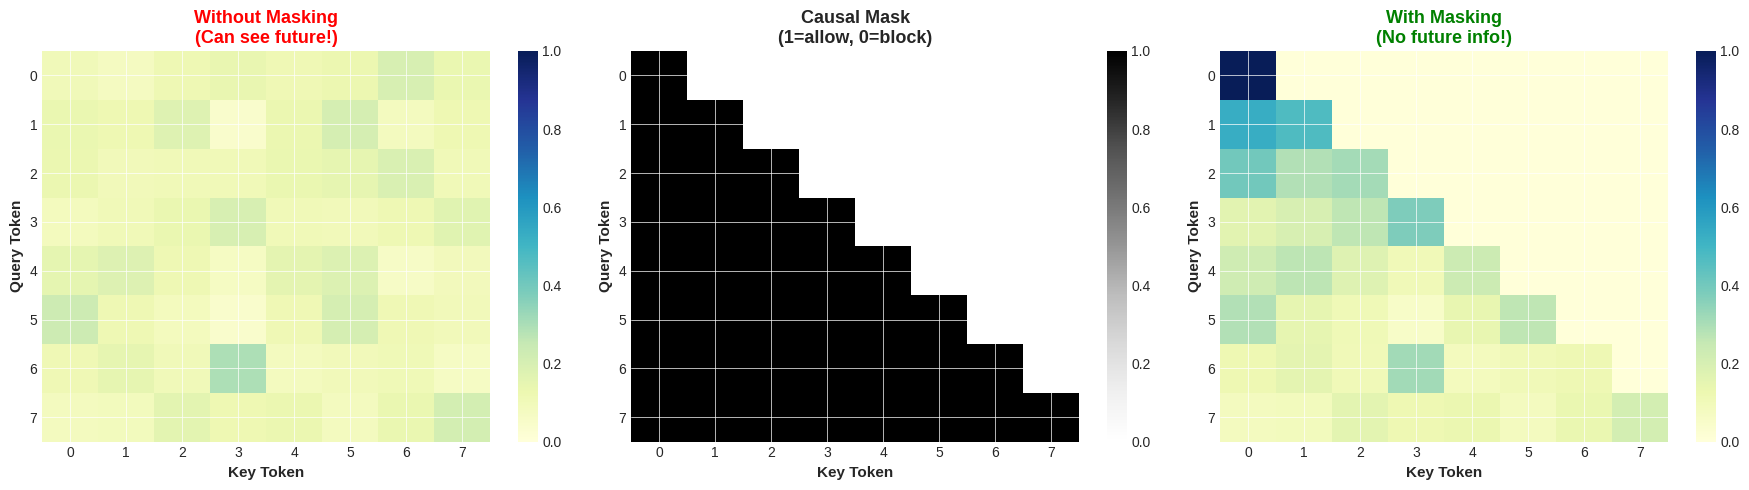


💡 Causal masking ensures autoregressive property!


In [19]:
# Visualize causal masking effect
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original (no mask)
im1 = axes[0].imshow(wei_softmax[0].detach().numpy(), cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
axes[0].set_xlabel('Key Token', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Query Token', fontsize=11, fontweight='bold')
axes[0].set_title('Without Masking\n(Can see future!)', fontsize=13, fontweight='bold', color='red')
axes[0].grid(which='both', color='white', linewidth=0.5)
plt.colorbar(im1, ax=axes[0])

# Mask
im2 = axes[1].imshow(tril.numpy(), cmap='Greys', aspect='auto', vmin=0, vmax=1)
axes[1].set_xlabel('Key Token', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Query Token', fontsize=11, fontweight='bold')
axes[1].set_title('Causal Mask\n(1=allow, 0=block)', fontsize=13, fontweight='bold')
axes[1].grid(which='both', color='white', linewidth=0.5)
plt.colorbar(im2, ax=axes[1])

# Masked attention
im3 = axes[2].imshow(wei_masked_softmax[0].detach().numpy(), cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
axes[2].set_xlabel('Key Token', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Query Token', fontsize=11, fontweight='bold')
axes[2].set_title('With Masking\n(No future info!)', fontsize=13, fontweight='bold', color='green')
axes[2].grid(which='both', color='white', linewidth=0.5)
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/causal_masking.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Causal masking ensures autoregressive property!")

# ┌─────────────────────────────────────────────────────────────────────┐
# │                  ATTENTION SCORE COMPUTATION                        │
# │                                                                     │
# │  Given: q shape (B, T, head_size), k shape (B, T, head_size)       │
# │                                                                     │
# │  Goal: For each query token, compute similarity with ALL key tokens│
# │                                                                     │
# │  Operation: q @ k.transpose(-2, -1)                                 │
# │    q:           (B, T, head_size)                                   │
# │    k.T:         (B, head_size, T)                                   │
# │    result:      (B, T, T)                                           │
# │                                                                     │
# │  Interpretation of result[i, j]:                                    │
# │    = dot product of query_i and key_j                               │
# │    = how similar/relevant is token j to token i?                    │
# │    = how much should token i attend to token j?                     │
# │                                                                     │
# │  Example: For token 3 (query_3):                                    │
# │    wei[3, 0] = similarity with token 0                              │
# │    wei[3, 1] = similarity with token 1                              │
# │    wei[3, 2] = similarity with token 2                              │
# │    ...                                                              │
# │    Higher score = more attention                                    │
# └─────────────────────────────────────────────────────────────────────┘

# Compute attention scores (affinities)
# q @ k.transpose(-2, -1) means: for each query, dot product with all keys
wei = q @ k.transpose(-2, -1)  # (B, T, T)

print(f"📊 Attention scores shape: {wei.shape}")
print(f"   (Batch, Query_Tokens, Key_Tokens)")
print(f"\n🔍 First sequence attention scores:")
print(wei[0])
print(f"\n💡 wei[i, j] = how much token i attends to token j")

In [20]:
# Perform weighted aggregation
out = wei_masked_softmax @ v  # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)

print(f"📊 Output shape: {out.shape}")
print(f"\n🔍 First token output:")
print(out[0, 0])

print(f"\n💡 Each token's output is a weighted combination of all (past) Values!")
print(f"   Token 0: Only sees itself (100% weight on position 0)")
print(f"   Token 3: Weighted average of positions 0, 1, 2, 3")
print(f"   Token 7: Weighted average of all 8 positions")

📊 Output shape: torch.Size([4, 8, 16])

🔍 First token output:
tensor([ 0.9188, -0.4802,  0.7133, -0.5937,  0.4444,  0.1345,  0.9416,  0.7107,
        -0.6756, -0.1056,  0.7853,  0.3268,  1.2301, -0.8469, -0.0181, -0.7070],
       grad_fn=<SelectBackward0>)

💡 Each token's output is a weighted combination of all (past) Values!
   Token 0: Only sees itself (100% weight on position 0)
   Token 3: Weighted average of positions 0, 1, 2, 3
   Token 7: Weighted average of all 8 positions


---

## 7. Complete Self-Attention Implementation

Let's put it all together in a clean class:

In [21]:
class SelfAttentionHead(nn.Module):
    """
    One head of self-attention.
    
    Args:
        n_embd: Embedding dimension
        head_size: Dimension of Q, K, V
        block_size: Maximum sequence length (for causal mask)
        dropout: Dropout probability
    """
    
    def __init__(self, n_embd, head_size, block_size, dropout=0.1):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        
        # Register causal mask as buffer (not a parameter)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        
        self.dropout = nn.Dropout(dropout)
        self.head_size = head_size
    
    def forward(self, x):
        """
        Args:
            x: Input embeddings, shape (B, T, C)
        
        Returns:
            out: Attention output, shape (B, T, head_size)
        """
        B, T, C = x.shape
        
        # Compute Q, K, V
        k = self.key(x)    # (B, T, head_size)
        q = self.query(x)  # (B, T, head_size)
        v = self.value(x)  # (B, T, head_size)
        
        # Compute attention scores
        wei = q @ k.transpose(-2, -1)  # (B, T, T)
        
        # Scale
        wei = wei / (self.head_size ** 0.5)
        
        # Apply causal mask
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        
        # Softmax
        wei = F.softmax(wei, dim=-1)
        
        # Apply dropout
        wei = self.dropout(wei)
        
        # Weighted aggregation
        out = wei @ v  # (B, T, head_size)
        
        return out

# Create attention head
attention_head = SelfAttentionHead(n_embd, head_size, block_size)

print(f"🧠 Self-Attention Head Created!")
print(f"\n📊 Parameters:")
print(f"   Input dim:  {n_embd}")
print(f"   Head size:  {head_size}")
print(f"   Block size: {block_size}")

# Count parameters
total_params = sum(p.numel() for p in attention_head.parameters())
print(f"\n💾 Total parameters: {total_params:,}")

🧠 Self-Attention Head Created!

📊 Parameters:
   Input dim:  32
   Head size:  16
   Block size: 8

💾 Total parameters: 1,536


In [22]:
# Test the attention head
test_input = torch.randn(4, 8, n_embd)
test_output = attention_head(test_input)

print(f"📥 Input shape:  {test_input.shape}")
print(f"📤 Output shape: {test_output.shape}")
print(f"\n✅ Self-attention head is working!")

📥 Input shape:  torch.Size([4, 8, 32])
📤 Output shape: torch.Size([4, 8, 16])

✅ Self-attention head is working!


---

## 8. Attention Visualization

Let's visualize what the attention head learns:

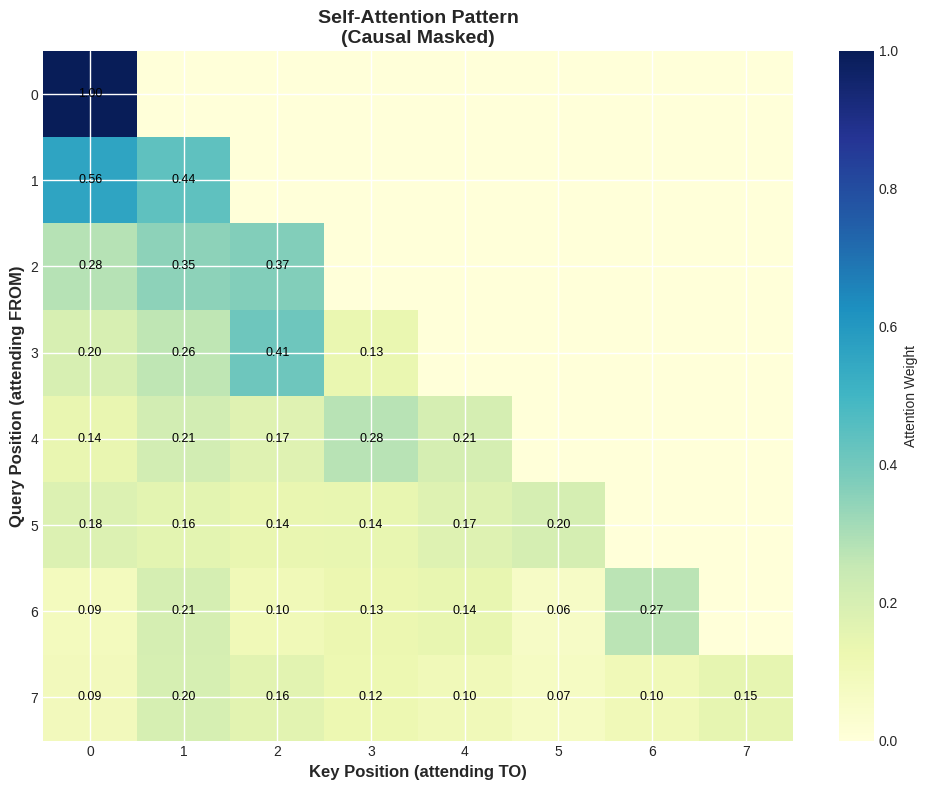


💡 Each row shows how much that token attends to previous tokens


In [23]:
# Create a simple sequence and visualize attention
with torch.no_grad():
    # Forward pass to get attention weights
    x_test = torch.randn(1, 8, n_embd)
    
    # Get intermediate values
    k = attention_head.key(x_test)
    q = attention_head.query(x_test)
    
    wei = q @ k.transpose(-2, -1) / (head_size ** 0.5)
    wei = wei.masked_fill(attention_head.tril[:8, :8] == 0, float('-inf'))
    wei = F.softmax(wei, dim=-1)

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(wei[0].numpy(), cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
ax.set_xlabel('Key Position (attending TO)', fontsize=12, fontweight='bold')
ax.set_ylabel('Query Position (attending FROM)', fontsize=12, fontweight='bold')
ax.set_title('Self-Attention Pattern\n(Causal Masked)', fontsize=14, fontweight='bold')

# Add values as text
for i in range(8):
    for j in range(8):
        if i >= j:  # Only show lower triangle
            text = ax.text(j, i, f'{wei[0, i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=9)

ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.grid(which='both', color='white', linewidth=1)

plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.savefig(f'{VIZ_DIR}/embeddings/attention_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Each row shows how much that token attends to previous tokens")

---

## 9. Key Takeaways

### ✅ What We Learned

1. **The Communication Problem**
   - Embeddings alone are independent
   - Tokens need to exchange information
   - Self-attention enables token communication

2. **Query, Key, Value (QKV)**
   - Query: "What am I looking for?"
   - Key: "What do I offer?"
   - Value: "What information do I contain?"
   - All derived from input via learned projections

3. **Attention Mechanism**
   ```
   Scores = (Q @ K^T) / √(head_size)
   Weights = softmax(Scores)
   Output = Weights @ V
   ```

4. **Scaled Dot-Product**
   - Scaling prevents gradient issues
   - Division by √(head_size) normalizes variance
   - Critical for training stability

5. **Causal Masking**
   - Prevents seeing future tokens
   - Essential for autoregressive generation
   - Implemented via lower triangular mask

6. **Shape Transformations**
   ```
   Input:  (B, T, C)
   Q,K,V:  (B, T, head_size)
   Scores: (B, T, T)
   Output: (B, T, head_size)
   ```

### 🎯 Key Insights

- **Attention is learned**: Q, K, V projections are trained
- **Attention is dynamic**: Weights change based on input
- **Attention is interpretable**: Can visualize what tokens attend to
- **Attention is powerful**: Enables long-range dependencies

### 🔮 What's Next?

In **Notebook 6**, we'll implement **Multi-Head Attention**:
- Multiple attention heads in parallel
- Different heads learn different patterns
- Concatenation and projection
- The full attention mechanism used in Transformers!

In [24]:
# Save the attention head
torch.save({
    'attention_head': attention_head.state_dict(),
    'n_embd': n_embd,
    'head_size': head_size,
    'block_size': block_size
}, f'{DATA_DIR}/attention_head.pth')

print("✅ Self-attention head saved to f'{DATA_DIR}/attention_head.pth'")

✅ Self-attention head saved to f'{DATA_DIR}/attention_head.pth'
